num-of-img: 7150


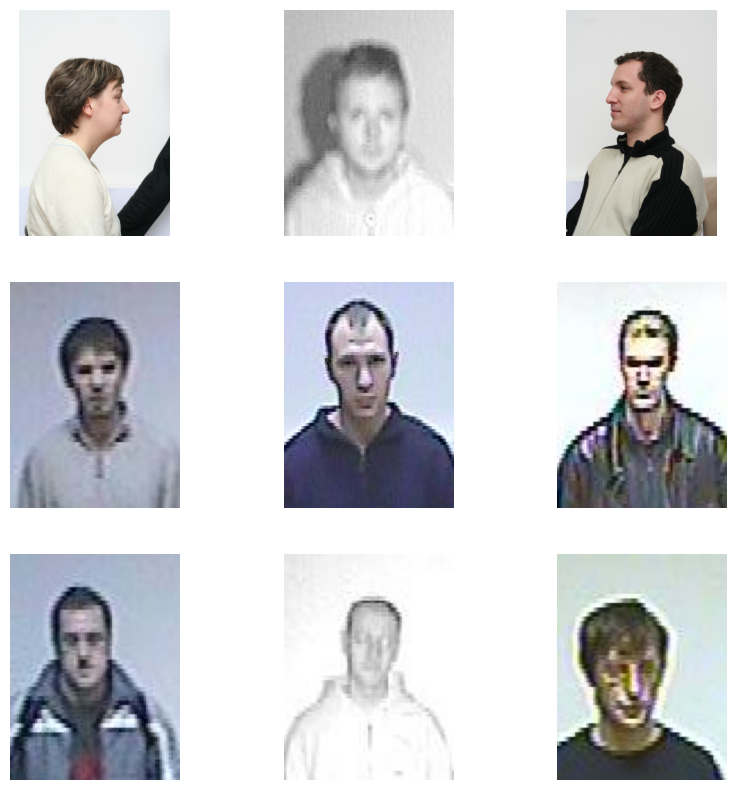

In [4]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/SCface_database"
all_images = []

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            all_images.append(os.path.join(root, f))

print("num-of-img:", len(all_images))

sample = random.sample(all_images, 9)
plt.figure(figsize=(10,10))

for i, path in enumerate(sample):
    img = Image.open(path)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


In [5]:
import os
import pandas as pd


data_list = []

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.ppm')):
            image_path = os.path.join(root, f)
            person_id = os.path.basename(root)

            if "mugshot" in root.lower():
                img_type = "Mugshot"
                distance = "Mugshot"
                camera = "Mugshot"
            elif "surveillance_cameras_distance_1" in root.lower():
                img_type = "Surveillance"
                distance = "1m"
                camera = os.path.basename(root)
            elif "surveillance_cameras_distance_2" in root.lower():
                img_type = "Surveillance"
                distance = "2m"
                camera = os.path.basename(root)
            elif "surveillance_cameras_distance_3" in root.lower():
                img_type = "Surveillance"
                distance = "3m"
                camera = os.path.basename(root)
            elif "IR" in root.lower():
                img_type = "IR"
                distance = "IR"
                camera = "IR_cam8"
            else:
                img_type = "Unknown"
                distance = "Unknown"
                camera = "Unknown"
            
            data_list.append([image_path, person_id, camera, distance, img_type])

df = pd.DataFrame(data_list, columns=["image_path","person_id","camera","distance","type"])
df.head()

,image_path,person_id,camera,distance,type
0,/kaggle/input/SCface_database/mugshot_frontal_...,mugshot_frontal_cropped_all,Mugshot,Mugshot,Mugshot
1,/kaggle/input/SCface_database/mugshot_frontal_...,mugshot_frontal_cropped_all,Mugshot,Mugshot,Mugshot
2,/kaggle/input/SCface_database/mugshot_frontal_...,mugshot_frontal_cropped_all,Mugshot,Mugshot,Mugshot
3,/kaggle/input/SCface_database/mugshot_frontal_...,mugshot_frontal_cropped_all,Mugshot,Mugshot,Mugshot
4,/kaggle/input/SCface_database/mugshot_frontal_...,mugshot_frontal_cropped_all,Mugshot,Mugshot,Mugshot


In [6]:
df.loc[df['image_path'].str.contains("surveillance_cameras_IR_cam8", case=False), 'type'] = "IR"
df.loc[df['image_path'].str.contains("surveillance_cameras_IR_cam8", case=False), 'distance'] = "IR"
df.loc[df['image_path'].str.contains("surveillance_cameras_IR_cam8", case=False), 'camera'] = "IR_cam8"


print(df['type'].value_counts())
print(df['distance'].value_counts())


type
Unknown         2860
Surveillance    2730
Mugshot         1430
IR               130
Name: count, dtype: int64
distance
Unknown    2860
Mugshot    1430
1m          910
3m          910
2m          910
IR          130
Name: count, dtype: int64


In [7]:
print("\n img-num of distance:")
print(df['distance'].value_counts())


 img-num of distance:
distance
Unknown    2860
Mugshot    1430
1m          910
3m          910
2m          910
IR          130
Name: count, dtype: int64


In [8]:
print("\n img-num of camera:")
print(df['camera'].value_counts())



 img-num of camera:
camera
Unknown    2860
Mugshot    1430
cam_3       390
cam_4       390
cam_6       390
cam_2       390
cam_5       390
cam_1       390
cam_7       390
IR_cam8     130
Name: count, dtype: int64


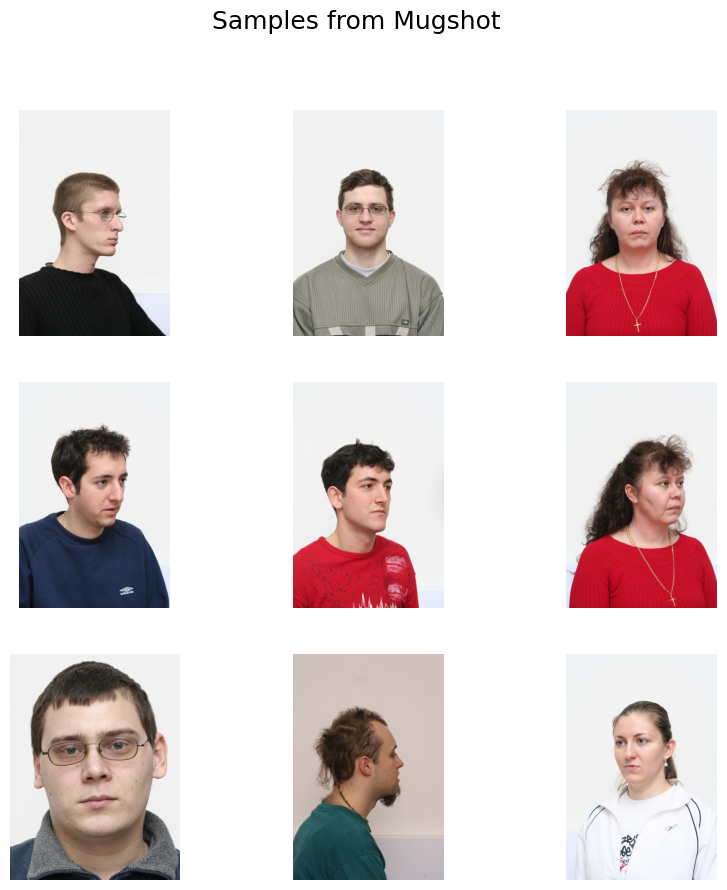

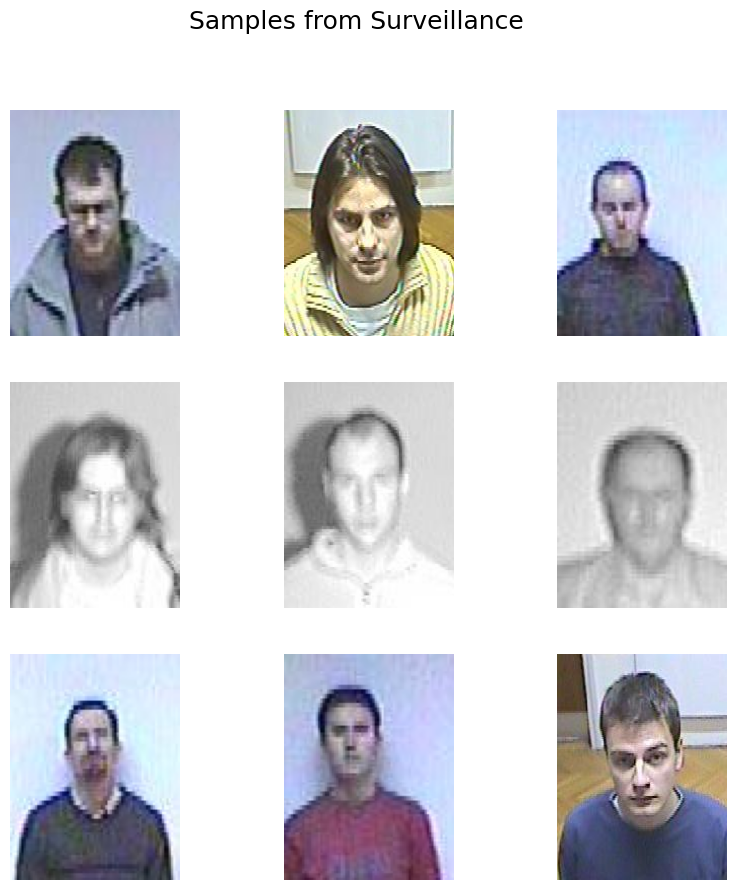

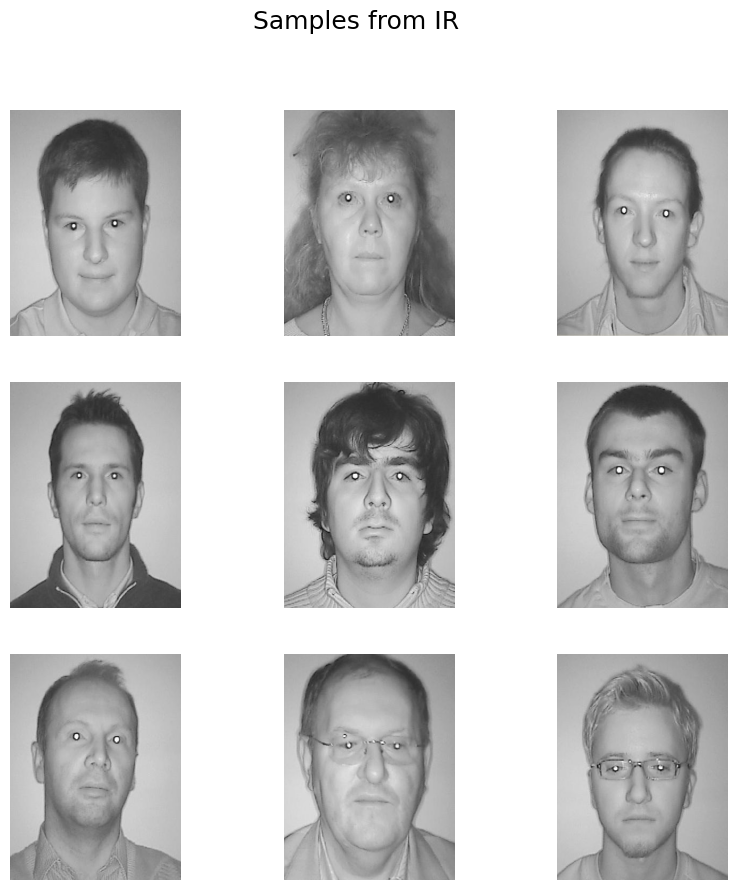

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples_by_type(img_type):
    paths = df[df['type']==img_type]['image_path'].tolist()
    sample = random.sample(paths, min(9, len(paths)))
    
    plt.figure(figsize=(10,10))
    for i, p in enumerate(sample):
        img = Image.open(p)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"Samples from {img_type}", fontsize=18)
    plt.show()

show_samples_by_type("Mugshot")
show_samples_by_type("Surveillance")
show_samples_by_type("IR")


Distance = 1m → image number  910


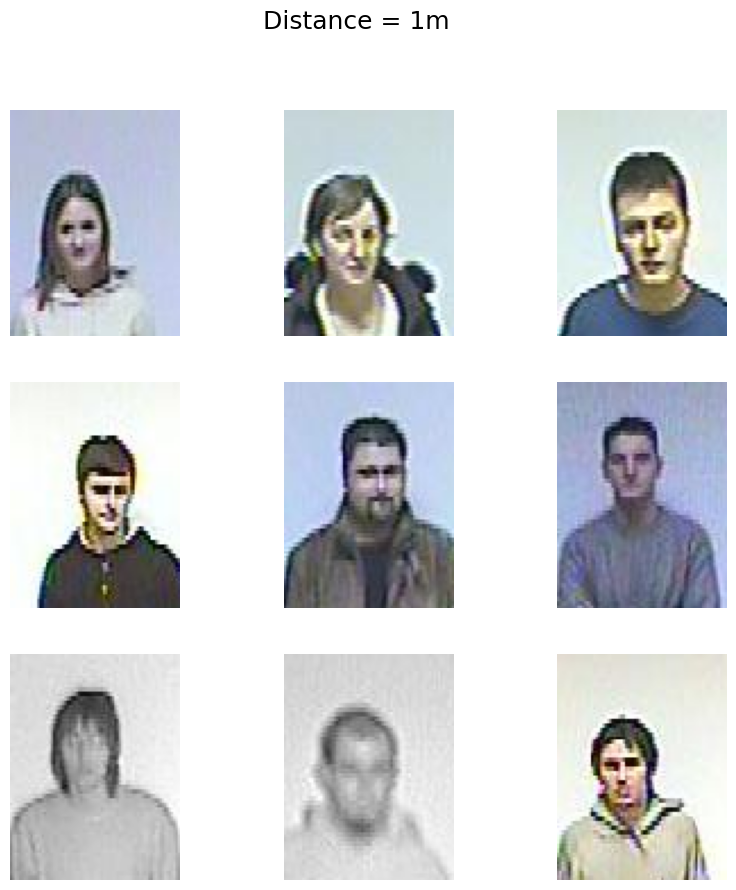

Distance = 2m → image number  910


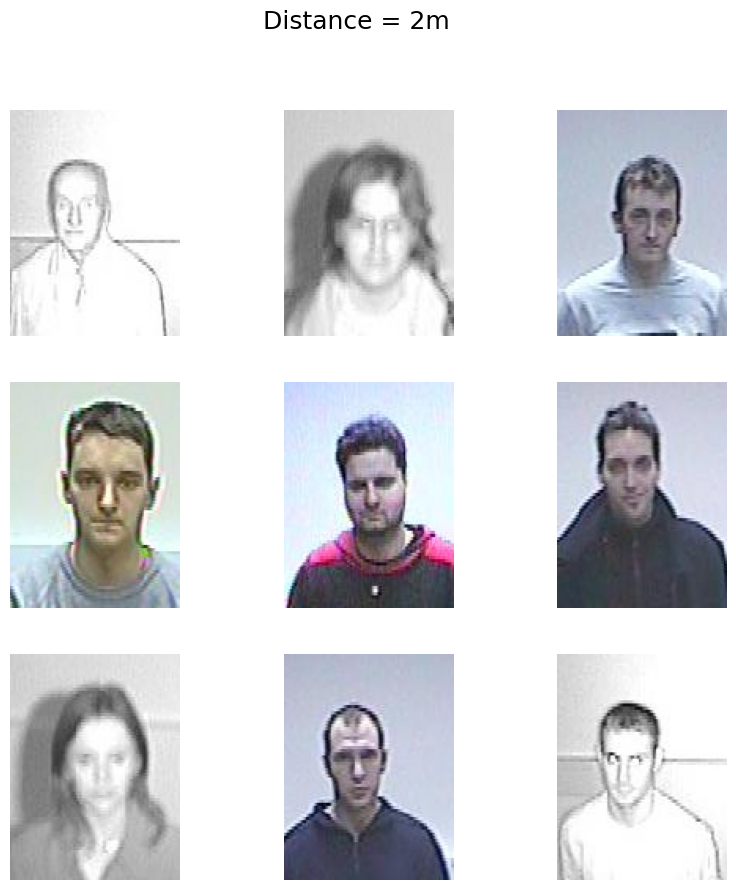

Distance = 3m → image number  910


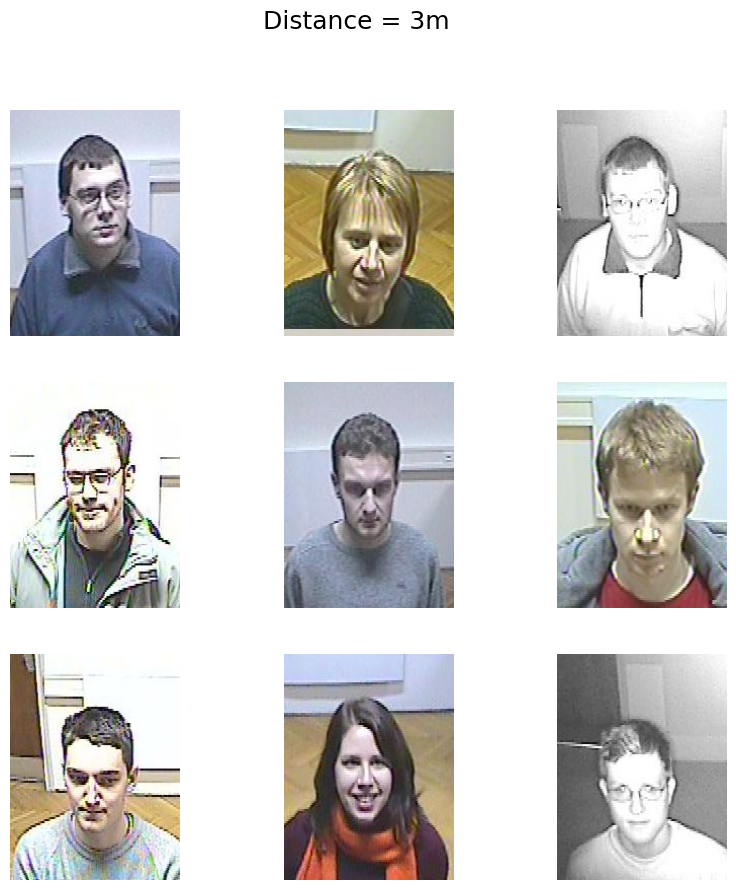

In [10]:
def show_samples(distance_path, title_text):
    paths = []

    for root, dirs, files in os.walk(distance_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.ppm')):
                paths.append(os.path.join(root, f))

    print(f"{title_text} → image number ", len(paths))

    sample = random.sample(paths, 9)

    plt.figure(figsize=(10,10))
    for i, p in enumerate(sample):
        img = Image.open(p)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title_text, fontsize=18)
    plt.show()


show_samples(DATA_DIR + "/surveillance_cameras_distance_1", "Distance = 1m")
show_samples(DATA_DIR + "/surveillance_cameras_distance_2", "Distance = 2m")
show_samples(DATA_DIR + "/surveillance_cameras_distance_3", "Distance = 3m")

# EDA -Milestone1

> Preliminary exploratory data analysis

In [11]:
import pandas as pd

records = []

for path in all_images:
    filename = path.split("/")[-1]
    folder = path.split("/")[-2]     
  
    pid = filename.split("_")[0].zfill(3)

    
    if "mugshot" in path.lower():
        img_type = "mugshot"
    elif "IR" in path or "ir" in path.lower():
        img_type = "infrared"
    else:
        img_type = "visible_surveillance"

    records.append({
        "image_path": path,
        "person_id": pid,
        "folder": folder,
        "type": img_type
    })

df_raw = pd.DataFrame(records)
df_raw.head()


,image_path,person_id,folder,type
0,/kaggle/input/SCface_database/mugshot_frontal_...,051,mugshot_frontal_cropped_all,mugshot
1,/kaggle/input/SCface_database/mugshot_frontal_...,074,mugshot_frontal_cropped_all,mugshot
2,/kaggle/input/SCface_database/mugshot_frontal_...,034,mugshot_frontal_cropped_all,mugshot
3,/kaggle/input/SCface_database/mugshot_frontal_...,043,mugshot_frontal_cropped_all,mugshot
4,/kaggle/input/SCface_database/mugshot_frontal_...,032,mugshot_frontal_cropped_all,mugshot


### ETL Workflow – Data Integration

To build a unified view of the SCFACE dataset, We:

1. Traversed all folders under the SCFACE root directory, including:
   - **surveillance_cameras_distance_1/2/3**
   - **surveillance_cameras_all**
   - **mugshot_frontal_**
   - **mugshot_rotation_all**
   - **surveillance_cameras_IR_cam8**
2. For each image file, We extracted:
   - **image_path** (full file path)
   - **person_id** (subject ID parsed from the filename)
   - **folder** (the immediate parent folder)
   - High-level metadata: **type**, **distance**  **camera**.
3. Combined all image records into a single dataframe `df_raw`, where **each row corresponds to one image**.


In [12]:
import re

def infer_distance_and_camera(row):
    path = row["image_path"].lower()
    folder = row["folder"].lower()

    
    distance = "Unknown"
    camera = "Unknown"

    
    if "surveillance_cameras_distance_1" in path:
        distance = "1m"
    elif "surveillance_cameras_distance_2" in path:
        distance = "2m"
    elif "surveillance_cameras_distance_3" in path:
        distance = "3m"

    
    cam_match = re.search(r"cam[_\-]?(\d+)", path)
    if cam_match:
        camera = f"cam_{cam_match.group(1)}"

   
    if "mugshot" in folder:
        distance = "Mugshot"
        camera = "Mugshot"

    
    if "surveillance_cameras_ir_cam8" in folder:
        distance = "IR"
        camera = "IR_cam8"

    return pd.Series({"distance": distance, "camera": camera})

meta = df_raw.apply(infer_distance_and_camera, axis=1)
df_raw = df_raw.drop(columns=['distance', 'camera'], errors='ignore')
df_raw = pd.concat([df_raw, meta], axis=1)


In [13]:

print("Total images:", len(df_raw))
print("Unique persons:", df_raw['person_id'].nunique())

print("\nImage count per type:")
print(df_raw['type'].value_counts())

print("\nImage count per distance:")
print(df_raw['distance'].value_counts())

print("\nImage count per camera:")
print(df_raw['camera'].value_counts())

person_counts = df_raw['person_id'].value_counts()

print("\n--- Images per person (summary statistics) ---")
print(person_counts.describe())


Total images: 7150
Unique persons: 130

Image count per type:
type
visible_surveillance    5590
mugshot                 1430
infrared                 130
Name: count, dtype: int64

Image count per distance:
distance
Unknown    2860
Mugshot    1430
1m          910
3m          910
2m          910
IR          130
Name: count, dtype: int64

Image count per camera:
camera
Mugshot    1430
cam_3       780
cam_4       780
cam_2       780
cam_6       780
cam_5       780
cam_1       780
cam_7       780
IR_cam8     130
cam_8       130
Name: count, dtype: int64

--- Images per person (summary statistics) ---
count    130.0
mean      55.0
std        0.0
min       55.0
25%       55.0
50%       55.0
75%       55.0
max       55.0
Name: count, dtype: float64


In [14]:

print("Missing values per column:")
print(df_raw.isnull().sum())

total_missing = df_raw.isnull().sum().sum()
print("\nTotal missing values in the dataset:", total_missing)

if total_missing == 0:
    print("\n No missing values detected.")
else:
    print("\n Missing values found. Consider cleaning or removing affected rows.")


Missing values per column:
image_path    0
person_id     0
folder        0
type          0
distance      0
camera        0
dtype: int64

Total missing values in the dataset: 0

 No missing values detected.


In [15]:

duplicate_count = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\n Duplicates found. Removing duplicates...")
    df_raw = df_raw.drop_duplicates()
    print("Duplicates removed. New dataset size:", len(df_raw))
else:
    print("\n No duplicate rows found.")


Number of duplicate rows: 0

 No duplicate rows found.


* Visualizations
* Correlations
*  Trends

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

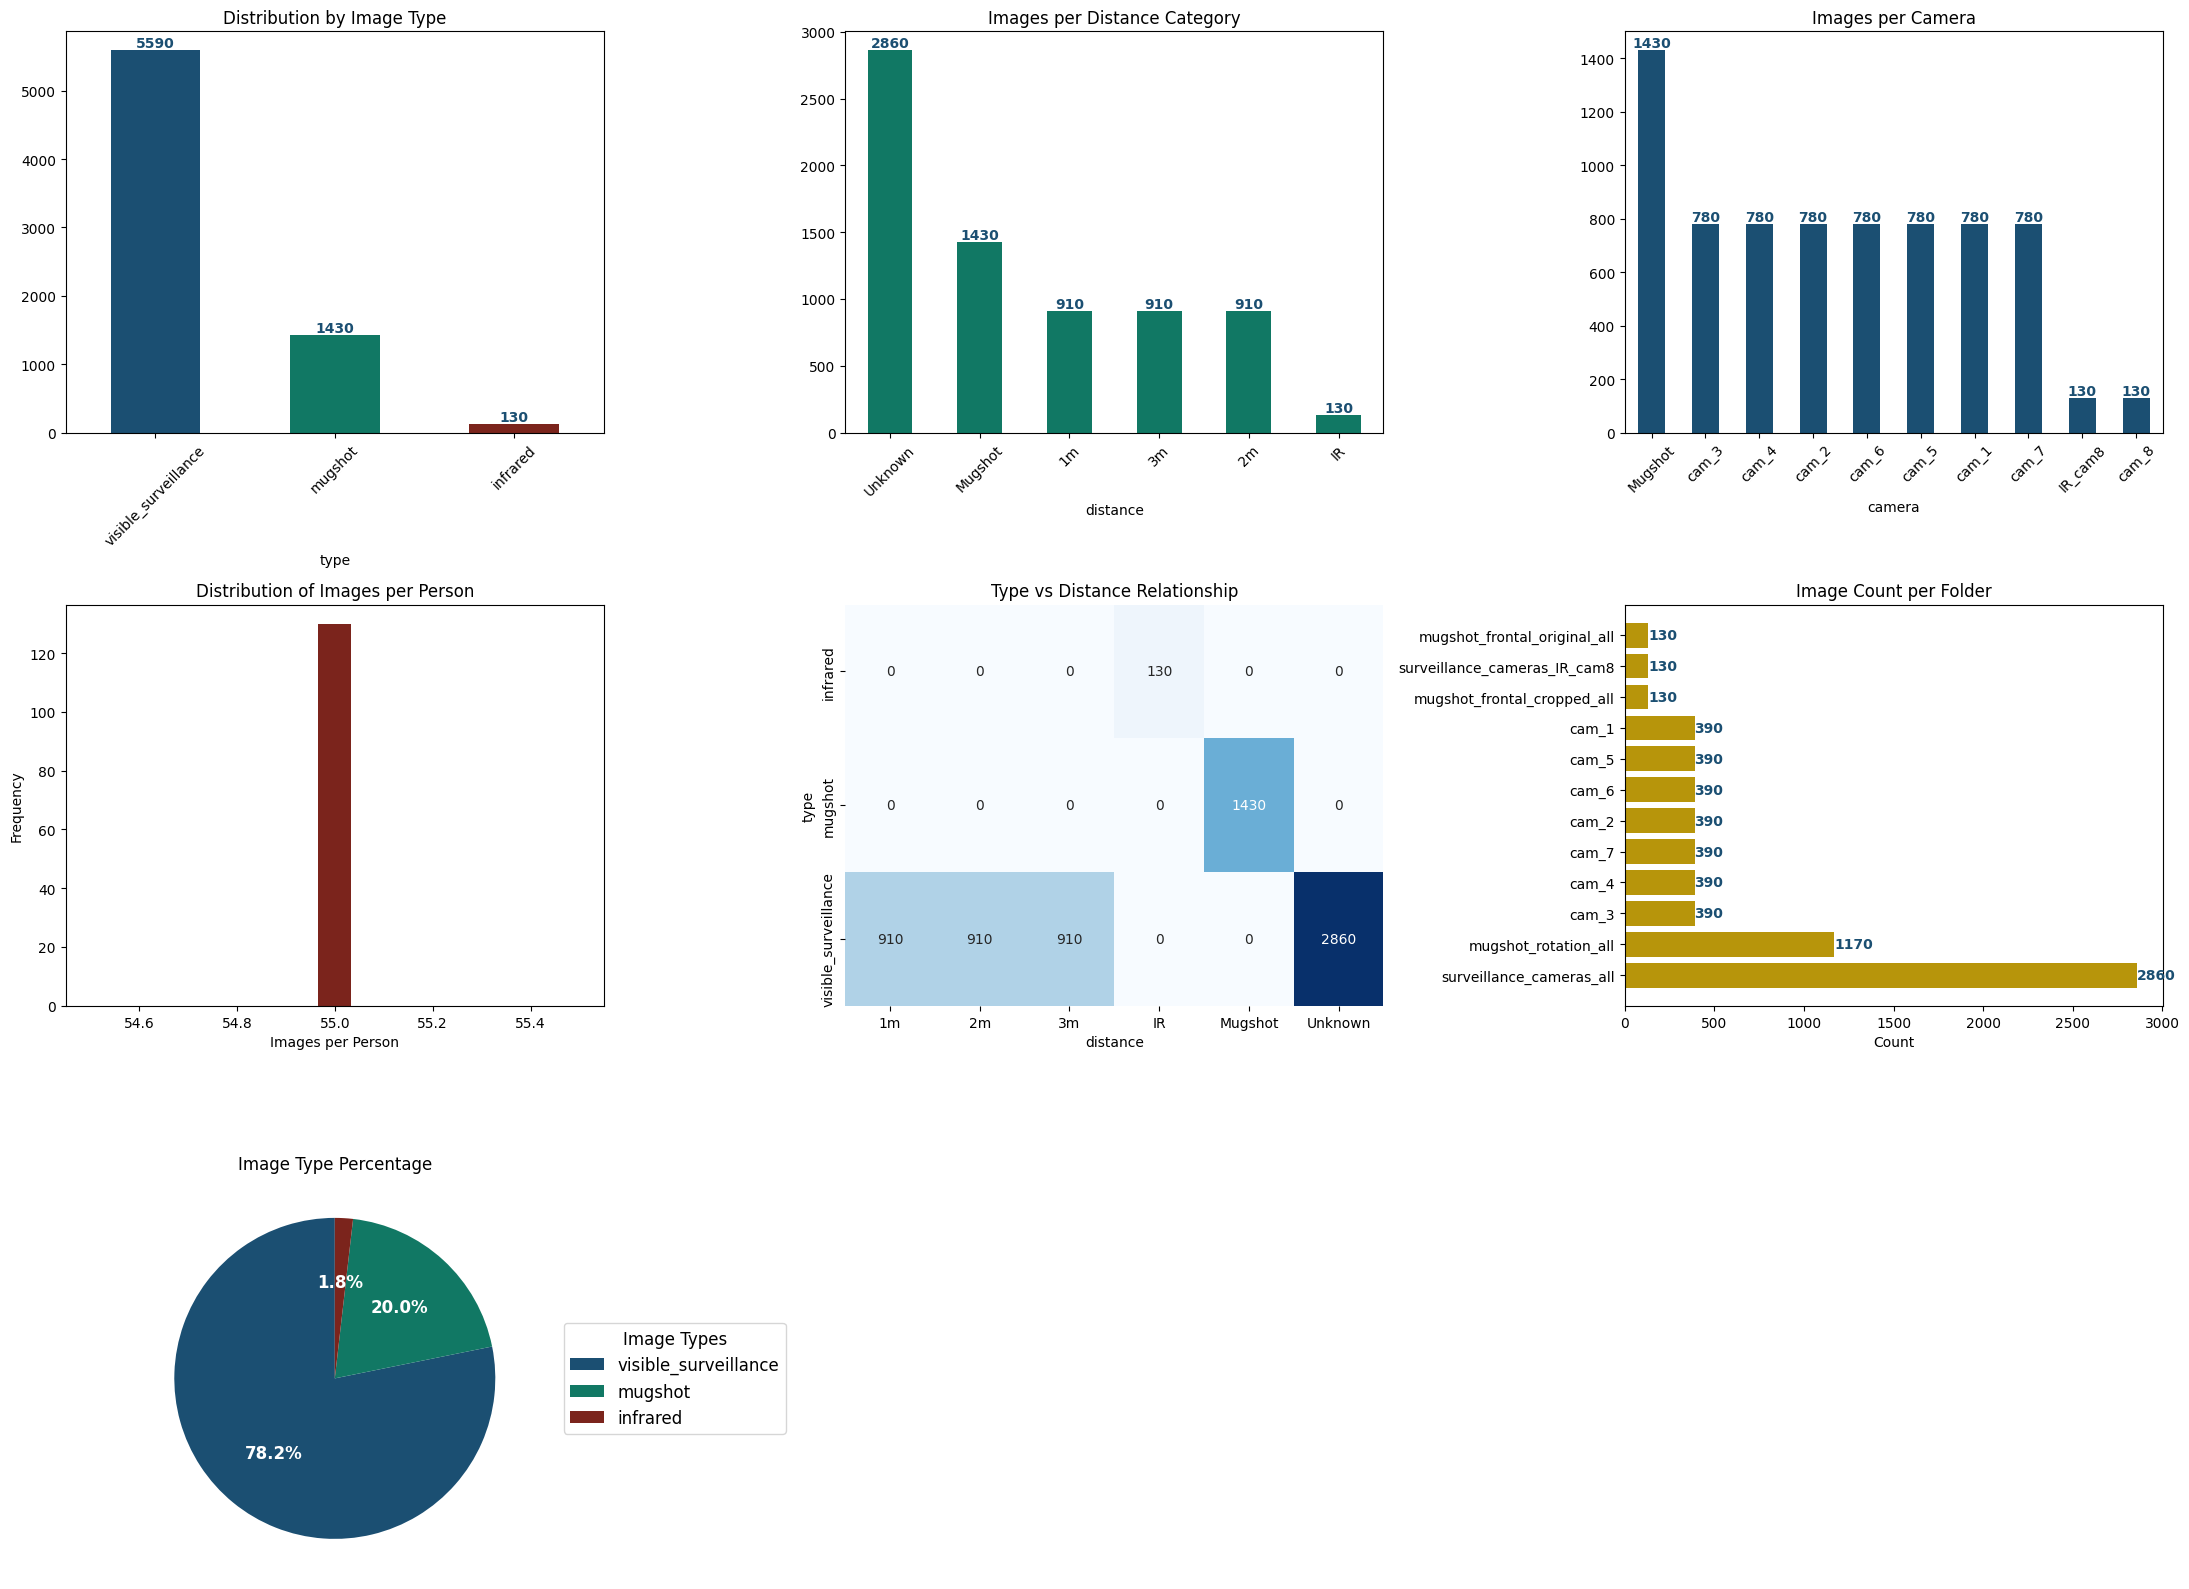

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap


def add_labels(ax):
    for p in ax.patches:
        value = int(p.get_height())
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_height(),
            value,
            ha='center', va='bottom',
            fontsize=10, color="#1B4F72", fontweight='bold'
        )
def add_labels_h(ax, values):
    for i, v in enumerate(values):
        ax.text(
            v,
            i,
            str(int(v)),
            va='center',
            ha='left',
            fontsize=10,
            color="#1B4F72",
            fontweight='bold'
        )



c1 = "#1B4F72"   
c2 = "#117864"   
c3 = "#7B241C"   
c4 = "#B7950B"   
c5 = "#5D6D7E"   

plt.figure(figsize=(22, 16))

# -------------------------------------------------------
plt.subplot(3, 3, 1)
ax1 = df_raw['type'].value_counts().plot(kind='bar', color=[c1, c2, c3, c4])
plt.title("Distribution by Image Type")
plt.xticks(rotation=45)
add_labels(ax1)

# -------------------------------------------------------
plt.subplot(3, 3, 2)
ax2 = df_raw['distance'].value_counts().plot(kind='bar', color=c2)
plt.title("Images per Distance Category")
plt.xticks(rotation=45)
add_labels(ax2)

# -------------------------------------------------------
plt.subplot(3, 3, 3)
ax3 = df_raw['camera'].value_counts().plot(kind='bar', color=c1)
plt.title("Images per Camera")
plt.xticks(rotation=45)
add_labels(ax3)

# ----------------------------------------

plt.subplot(3, 3, 4)

counts = df_raw['person_id'].value_counts()
n, bins, patches = plt.hist(counts, bins=15, color=c3)

plt.title("Distribution of Images per Person")
plt.xlabel("Images per Person")
plt.ylabel("Frequency")

if len(n) == 1:
    plt.text(
        bins[0] + (bins[1] - bins[0]) / 2,
        n[0],
        str(int(n[0])),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color=c1
    )

# ---------------------------------------
plt.subplot(3, 3, 5)
heatmap_data = df_raw.groupby(['type', 'distance']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Type vs Distance Relationship")

# -------------------------------------------
plt.subplot(3, 3, 6)
folder_counts = df_raw['folder'].value_counts()

ax6 = plt.barh(folder_counts.index, folder_counts.values, color=c4)
plt.title("Image Count per Folder")
plt.xlabel("Count")

add_labels_h(plt.gca(), folder_counts.values)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

# -------------------------------------------

plt.subplot(3, 3, 7)

pie_counts = df_raw['type'].value_counts()
labels = pie_counts.index
colors = [c1, c2, c3, c4]

patches, texts, autotexts = plt.pie(
    pie_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'color': 'white', 'fontsize': 11}
)

for a in autotexts:
    a.set_fontsize(12)
    a.set_weight('bold')

plt.title("Image Type Percentage")
plt.ylabel("")

plt.legend(
    patches, labels,
    title="Image Types",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=12,
    title_fontsize=12
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


### Tools and Technologies

- **Environment:** Kaggle Notebook 
- **Programming language:** Python
- **Data source:** SCFACE face recognition dataset from (Kaggle)
- **ETL and data processing:**
  - "os" for file system traversal and folder inspection
  - "pandas" for building tabular datasets (df_raw) and data cleaning
  - "numpy" for basic numerical operations
- **Image handling:**
  - "PIL" for loading and converting images
- **Visualization:**
  - "'matplotlib" and "seaborn" for plots, bar charts, histograms, and heatmaps


In [18]:
import json

schema_m1 = {
    "project": "SCFace - Face Recognition in Surveillance Conditions",
    "table_name": "df_raw",
    "num_rows": int(len(df_raw)),
    "num_columns": df_raw.shape[1],
    "columns": {
        "image_path": {
            "type": "string",
            "description": "Full file path to the original image."
        },
        "person_id": {
            "type": "categorical",
            "description": "Subject ID extracted from filename (001–130)."
        },
        "folder": {
            "type": "string",
            "description": "The directory where the image was found (e.g., cam_1, mugshot_rotation_all)."
        },
        "type": {
            "type": "categorical",
            "description": "High-level category: visible_surveillance, mugshot, infrared, or augmented."
        },
        "distance": {
            "type": "categorical",
            "description": "1m, 2m, 3m, Mugshot, IR, or Unknown (for augmented images)."
        },
        "camera": {
            "type": "categorical",
            "description": "Camera identifier: cam_1–cam_7, IR_cam8, Mugshot, or Unknown."
        }
    },
    "entities": {
        "Person": {
            "primary_key": "person_id",
            "description": "Represents one of the 130 subjects in SCFACE."
        },
        "Image": {
            "primary_key": "image_path",
            "description": "Each row corresponds to a single image."
        }
    },
    "relationships": [
        "Person (1) --- (N) Image  via person_id"
    ]
}

with open("Milestone1_Data_Schema.json", "w") as f:
    json.dump(schema_m1, f, indent=4)

print("Saved Milestone1_Data_Schema.json")


Saved Milestone1_Data_Schema.json


### Entity–Relationship Documentation

The dataset contains one main table (df_raw) containing all SCFACE images.  
Two conceptual entities exist:

---

#### **Entity 1 — Person**
- Primary key: `person_id`
- Description: Each of the 130 subjects in SCFACE.

#### **Entity 2 — Image**
- Primary key: `image_path`
- Attributes: `folder`, `type`, `distance`, `camera`
- Description: Each row corresponds to one face image (mugshot, surveillance, IR, or augmented).

---

### **Relationship**
There is a **one-to-many** relationship between Person and Image:



# Milestone2

In [19]:
import os

PROCESSED_DIR = "./processed_scface_images"
os.makedirs(PROCESSED_DIR, exist_ok=True)

IMG_SIZE = 224  # Standard size for ML models


> Resize → Convert to RGB → Save

  
*  Loads an image, converts it to RGB, resizes it to a fixed dimension,    and returns the processed PIL image.    *


In [20]:
from PIL import Image

def process_image(path, img_size=IMG_SIZE):
    img = Image.open(path)
    img = img.convert("RGB")
    img = img.resize((img_size, img_size))
    return img


In [21]:
processed_records = []

for idx, row in df_raw.iterrows():
    raw_path = row["image_path"]
    person_id = row["person_id"]

    try:
        img_proc = process_image(raw_path)

        new_filename = f"person{person_id}_img{idx:05d}.jpg"
        new_path = os.path.join(PROCESSED_DIR, new_filename)

        img_proc.save(new_path)

        processed_records.append({
            "person_id": person_id,
            "raw_path": raw_path,
            "processed_path": new_path,
            "type": row["type"],
            "distance": row["distance"],
            "camera": row["camera"],
        })

    except Exception as e:
        print("Error processing:", raw_path, e)


In [22]:
df_processed = pd.DataFrame(processed_records)
df_processed.head()


,person_id,raw_path,processed_path,type,distance,camera
0,051,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person051_img00000.jpg,mugshot,Mugshot,Mugshot
1,074,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person074_img00001.jpg,mugshot,Mugshot,Mugshot
2,034,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person034_img00002.jpg,mugshot,Mugshot,Mugshot
3,043,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person043_img00003.jpg,mugshot,Mugshot,Mugshot
4,032,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person032_img00004.jpg,mugshot,Mugshot,Mugshot


# Feature Engineering (brightness + blur + contrast)

In [23]:
import numpy as np
import cv2

brightness_values = []
blur_values = []
contrast_values = []

for p in df_processed["processed_path"]:
    img = Image.open(p).convert("L")
    img_np = np.array(img)

    
    brightness_values.append(img_np.mean())

    
    blur_values.append(cv2.Laplacian(img_np, cv2.CV_64F).var())
    
    contrast_values.append(img_np.std())



In [24]:
df_processed["brightness"] = brightness_values
df_processed["blur"] = blur_values
df_processed["contrast"] = contrast_values


In [25]:
print("Processed image size check:")
sizes = set()

for p in df_processed["processed_path"]:
    img = Image.open(p)
    sizes.add(img.size)

print(sizes)  


Processed image size check:
{(224, 224)}


In [26]:
print(df_processed.isnull().sum())


person_id         0
raw_path          0
processed_path    0
type              0
distance          0
camera            0
brightness        0
blur              0
contrast          0
dtype: int64


In [27]:
print("Unique persons:", df_processed['person_id'].nunique())
print("Total processed images:", len(df_processed))
print("Total raw images:", len(df_raw))


Unique persons: 130
Total processed images: 7150
Total raw images: 7150


In [28]:
df_processed.to_csv("SCFACE_processed_metadata.csv", index=False)
print("Saved processed metadata file.")


Saved processed metadata file.


### Data Lineage and Metadata Documentation


1. **Raw input (df_raw):**
   - Contains all original and augmented image paths.
   - Includes metadata: type, distance, camera, folder, and person_id.

2. **Image transformation:**
   - All images converted to RGB format.
   - Uniform resizing to 224 × 224 pixels.
   - Saved into a structured directory

3. **Processed output (df_processed):**
   - Contains paths to both raw and processed images.
   - Inherits metadata from df_raw.
   - Adds engineered features:
     - `brightness`: average grayscale intensity
     - `blur`: Laplacian variance (image sharpness)

4. **Validation checks:**
   - Verified identical image count between raw and processed datasets.
   - Ensured consistent image dimensions.
   - Confirmed no missing values after processing.



# Show images before Processed and after

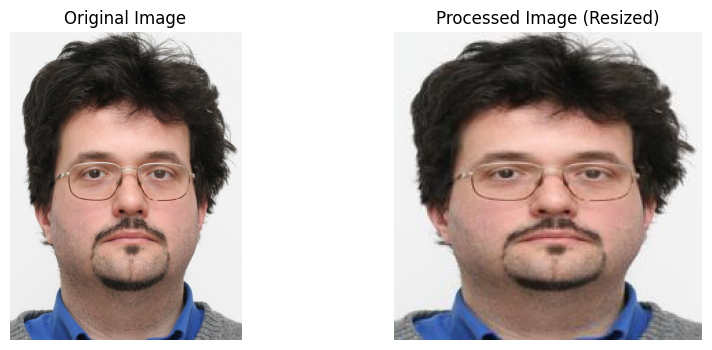

In [29]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

row = df_processed.iloc[0]

raw_img = Image.open(row["raw_path"])
proc_img = Image.open(row["processed_path"])

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(proc_img)
plt.title("Processed Image (Resized)")
plt.axis("off")

plt.show()


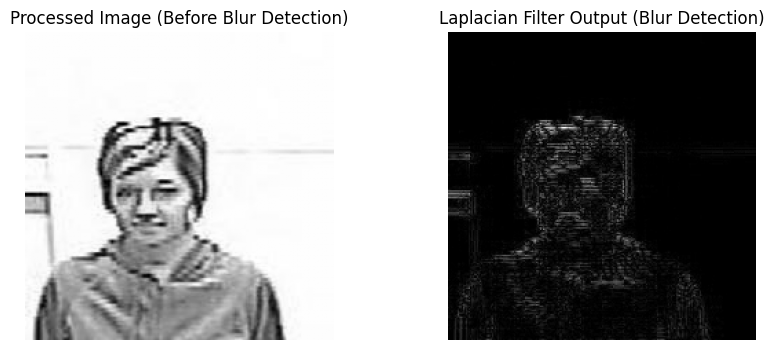

In [30]:
row = df_processed.sample(1).iloc[0]


img = Image.open(row["processed_path"]).convert("L")
img_np = np.array(img)


laplacian = cv2.Laplacian(img_np, cv2.CV_64F)

plt.figure(figsize=(10,4))

#  before 
plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title("Processed Image (Before Blur Detection)")
plt.axis("off")

#  after 
plt.subplot(1, 2, 2)
plt.imshow(np.absolute(laplacian), cmap='gray')
plt.title("Laplacian Filter Output (Blur Detection)")
plt.axis("off")

plt.show()


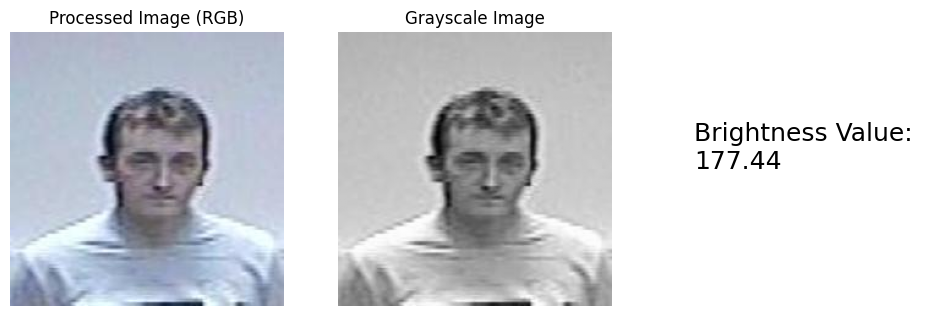

Brightness value (saved in df): 177.43879544005102


In [31]:
row = df_processed.sample(1).iloc[0]

img_rgb = Image.open(row["processed_path"]).convert("RGB")

img_gray = Image.open(row["processed_path"]).convert("L")
img_gray_np = np.array(img_gray)

brightness_value = img_gray_np.mean()

plt.figure(figsize=(12,4))


plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Processed Image (RGB)")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(img_gray_np, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


plt.subplot(1, 3, 3)
plt.text(0.1, 0.5, f"Brightness Value:\n{brightness_value:.2f}",
         fontsize=18)
plt.axis("off")

plt.show()

print("Brightness value (saved in df):", row["brightness"])


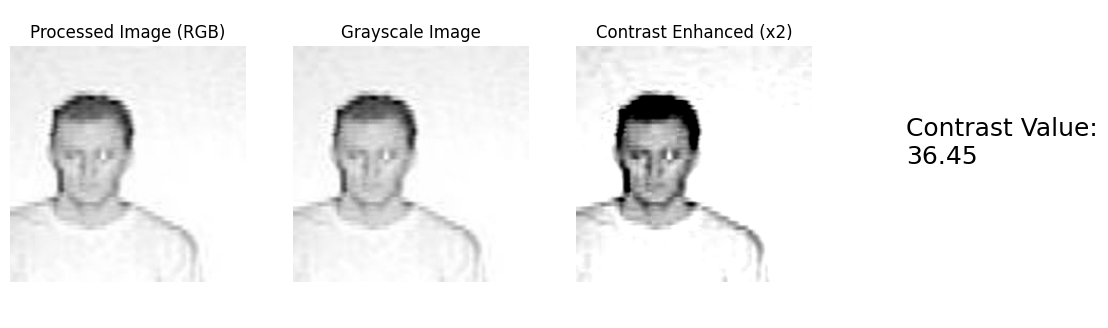

Contrast value (saved in df): 36.45150545739038


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

row = df_processed.sample(1).iloc[0]

img_rgb = Image.open(row["processed_path"]).convert("RGB")

img_gray = Image.open(row["processed_path"]).convert("L")
img_gray_np = np.array(img_gray)

enhancer = ImageEnhance.Contrast(img_gray)
img_contrast_enhanced = enhancer.enhance(2.0)  

contrast_value = row["contrast"]

plt.figure(figsize=(14, 4))


plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Processed Image (RGB)")
plt.axis("off")

 
plt.subplot(1, 4, 2)
plt.imshow(img_gray_np, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


plt.subplot(1, 4, 3)
plt.imshow(img_contrast_enhanced, cmap="gray")
plt.title("Contrast Enhanced (x2)")
plt.axis("off")


plt.subplot(1, 4, 4)
plt.text(0.2, 0.5, f"Contrast Value:\n{contrast_value:.2f}", fontsize=18)
plt.axis("off")

plt.show()

print("Contrast value (saved in df):", contrast_value)


In [33]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# **Milestone 3 — Data Analytics & Machine Learning**

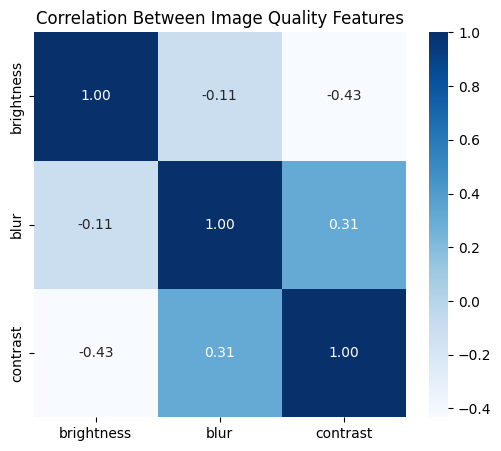

In [34]:
features = df_processed[["brightness", "blur", "contrast"]]

plt.figure(figsize=(6,5))
sns.heatmap(features.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Image Quality Features")
plt.show()


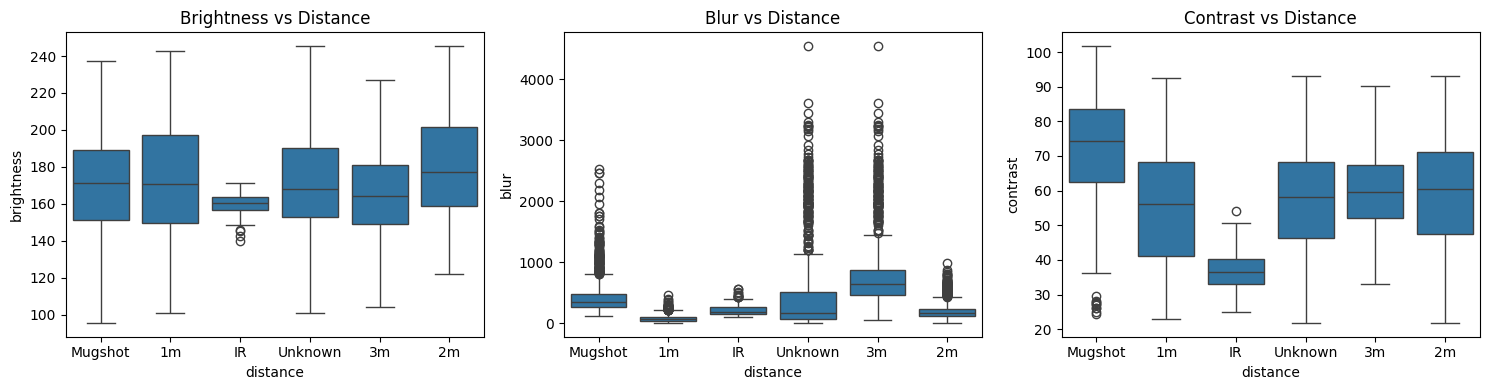

In [35]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(data=df_processed, x="distance", y="brightness")
plt.title("Brightness vs Distance")

plt.subplot(1,3,2)
sns.boxplot(data=df_processed, x="distance", y="blur")
plt.title("Blur vs Distance")

plt.subplot(1,3,3)
sns.boxplot(data=df_processed, x="distance", y="contrast")
plt.title("Contrast vs Distance")

plt.tight_layout()
plt.show()


In [40]:
pip install deepface


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
!pip install deepface opencv-python-headless scikit-learn pandas numpy matplotlib seaborn

In [42]:
import sys
!{sys.executable} -m pip install deepface


In [43]:
!ping pypi.org


/bin/bash: line 1: ping: command not found


In [44]:
import os
import cv2
import numpy as np
import pandas as pd

from deepface import DeepFace

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

2025-12-27 15:53:00.150852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766850780.333712      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766850780.387466      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766850780.822628      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766850780.822665      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766850780.822668      55 computation_placer.cc:177] computation placer alr

25-12-27 15:53:12 - Directory /root/.deepface has been created
25-12-27 15:53:12 - Directory /root/.deepface/weights has been created


In [46]:
df_processed.to_csv("SCFACE_processed_metadata.csv", index=False)
df = pd.read_csv("SCFACE_processed_metadata.csv")  
df.head()

,person_id,raw_path,processed_path,type,distance,camera,brightness,blur,contrast
0,51,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person051_img00000.jpg,mugshot,Mugshot,Mugshot,142.320233,561.048574,77.252314
1,74,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person074_img00001.jpg,mugshot,Mugshot,Mugshot,140.666733,556.707961,80.073746
2,34,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person034_img00002.jpg,mugshot,Mugshot,Mugshot,168.235651,413.493627,75.207860
3,43,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person043_img00003.jpg,mugshot,Mugshot,Mugshot,172.014290,251.150211,68.390906
4,32,/kaggle/input/SCface_database/mugshot_frontal_...,./processed_scface_images/person032_img00004.jpg,mugshot,Mugshot,Mugshot,106.570930,369.802112,75.818330


In [47]:
def extract_embedding(img_path):
    try:
        embedding = DeepFace.represent(
            img_path=img_path,
            model_name="Facenet",
            enforce_detection=False
        )
        return embedding[0]["embedding"]
    except:
        return None

In [49]:
from deepface import DeepFace
import numpy as np
import pandas as pd

embeddings = []
labels = []

for _, row in df_processed.iterrows():
    try:
        rep = DeepFace.represent(
            img_path=row["processed_path"],
            model_name="Facenet",
            enforce_detection=False
        )
        embeddings.append(rep[0]["embedding"])
        labels.append(row["person_id"])
    except:
        continue

X = np.array(embeddings)
y = np.array(labels)

I0000 00:00:1766851136.721156      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766851136.725099      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


25-12-27 15:58:59 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:01<00:00, 91.9MB/s]
I0000 00:00:1766851141.478113      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


In [50]:
df["embedding"] = df["processed_path"].apply(extract_embedding)

df = df[df["embedding"].notnull()]

print("Number of images after embedding:", len(df))

Number of images after embedding: 7150


In [53]:
X = np.vstack(df["embedding"].values)   
y = df["person_id"]

In [56]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================
# Face Recognition: X = embeddings, y = person_id



df_fr = df.dropna(subset=["embedding", "person_id"]).copy()


counts = df_fr["person_id"].value_counts()
df_fr = df_fr[df_fr["person_id"].isin(counts[counts >= 2].index)].copy()


train_df, test_df = train_test_split(
    df_fr,
    test_size=0.25,
    random_state=42,
    stratify=df_fr["person_id"]
)


X_train = np.vstack(train_df["embedding"].values)
X_test  = np.vstack(test_df["embedding"].values)


y_train = train_df["person_id"].values
y_test  = test_df["person_id"].values


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
#==============================================================================================
quality_df = df_processed[
    df_processed["distance"].isin(["1m", "2m", "3m"])
]

quality_summary = (
    quality_df
    .groupby("distance")[["brightness", "blur", "contrast"]]
    .agg(["mean", "std"])
)

quality_summary


brightness                   blur               contrast           
                mean        std        mean         std       mean        std
distance                                                                     
1m        174.610306  30.235454   86.556845   64.076897  55.657253  16.315219
2m        181.371429  28.265380  213.266593  159.228500  59.486256  15.358426
3m        165.198321  21.555364  816.834722  668.234562  60.217372  10.798979

In [78]:
import numpy as np
from tqdm import tqdm
from deepface import DeepFace

def extract_embedding(path, model_name="Facenet", enforce_detection=False):
    try:
        rep = DeepFace.represent(
            img_path=path,
            model_name=model_name,
            enforce_detection=enforce_detection
        )
        return np.array(rep[0]["embedding"], dtype=np.float32)
    except:
        return None

def embed_paths(paths, model_name="Facenet"):
    embs = []
    for p in tqdm(paths, desc="Embedding degraded"):
        embs.append(extract_embedding(p, model_name=model_name))
    return embs


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.86      0.86      0.86        14
           3       0.83      0.71      0.77        14
           4       0.91      0.71      0.80        14
           5       0.21      0.46      0.29        13
           6       0.40      0.71      0.51        14
           7       0.69      0.64      0.67        14
           8       0.60      0.86      0.71        14
           9       1.00      0.79      0.88        14
          10       0.86      0.86      0.86        14
          11       0.85      0.85      0.85        13
          12       0.92      0.85      0.88        13
          13       0.82      0.69      0.75        13
          14       0.75      0.64      0.69        14
          15       0.53      0.64      0.58        14
          16       0.91      0.71      0.80        14
          17       0.69      0.64      0.67        14
          18       0.89    

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(
    n_neighbors=3,       
    metric="cosine"
)

knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print("KNN (cosine) acc:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


KNN (cosine) acc: 0.5782997762863534
              precision    recall  f1-score   support

           1       0.52      1.00      0.68        13
           2       0.41      0.50      0.45        14
           3       0.60      0.64      0.62        14
           4       0.35      0.79      0.49        14
           5       0.40      0.77      0.53        13
           6       0.53      0.64      0.58        14
           7       0.60      0.64      0.62        14
           8       0.55      0.86      0.67        14
           9       0.50      0.64      0.56        14
          10       0.43      0.64      0.51        14
          11       0.41      0.69      0.51        13
          12       0.36      0.77      0.49        13
          13       0.59      0.77      0.67        13
          14       0.53      0.71      0.61        14
          15       0.52      0.79      0.63        14
          16       0.64      0.50      0.56        14
          17       0.37      0.50      0.42 

In [59]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           1       0.93      1.00      0.96        13
           2       0.77      0.71      0.74        14
           3       0.85      0.79      0.81        14
           4       0.55      0.86      0.67        14
           5       0.43      0.92      0.59        13
           6       0.78      1.00      0.88        14
           7       0.88      1.00      0.93        14
           8       0.81      0.93      0.87        14
           9       0.75      0.86      0.80        14
          10       0.86      0.86      0.86        14
          11       1.00      0.77      0.87        13
          12       0.76      1.00      0.87        13
          13       0.69      0.69      0.69        13
          14       0.85      0.79      0.81        14
          15       0.67      0.86      0.75        14
          16       0.92      0.79      0.85        14
          17       0.56      0.71      0.62        14
          18       0.79    

In [60]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=1.0, max_iter=5000))
])

svm.fit(X_train, y_train)
pred = svm.predict(X_test)

print("LinearSVC acc:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


LinearSVC acc: 0.7007829977628636
              precision    recall  f1-score   support

           1       0.85      0.85      0.85        13
           2       0.55      0.43      0.48        14
           3       0.67      0.71      0.69        14
           4       0.77      0.71      0.74        14
           5       0.57      0.62      0.59        13
           6       0.33      0.57      0.42        14
           7       0.53      0.64      0.58        14
           8       0.52      0.86      0.65        14
           9       0.71      0.71      0.71        14
          10       0.85      0.79      0.81        14
          11       0.91      0.77      0.83        13
          12       0.92      0.85      0.88        13
          13       0.60      0.69      0.64        13
          14       0.44      0.57      0.50        14
          15       0.75      0.64      0.69        14
          16       0.73      0.57      0.64        14
          17       0.80      0.57      0.67    

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

def visual_test_predictions(
    model,
    test_df,
    X_test,
    y_test,
    n=12,
    img_col="processed_path",
    seed=42,
    figsize=(16, 10)
):
    y_test_np = y_test.detach().cpu().numpy() if hasattr(y_test, "detach") else np.array(y_test)

    assert len(test_df) == len(X_test) == len(y_test_np), \
        f"Lengths mismatch: test_df={len(test_df)}, X_test={len(X_test)}, y_test={len(y_test_np)}"

    y_pred = model.predict(X_test)

    rng = random.Random(seed)
    idxs = rng.sample(range(len(test_df)), k=min(n, len(test_df)))

    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax_i, i in enumerate(idxs):
        ax = axes[ax_i]
        path = test_df.loc[i, img_col]

        try:
            img = Image.open(path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Load failed:\n{e}", ha="center", va="center", fontsize=9)
            ax.axis("off")
            continue

        true_label = y_test_np[i]
        pred_label = y_pred[i]
        ok = (pred_label == true_label)

        ax.set_title(f"True: {true_label} | Pred: {pred_label} {'✅' if ok else '❌'}", fontsize=11)
        ax.axis("off")

    for j in range(len(idxs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [72]:
test_df = test_df.reset_index(drop=True)


# visualization of test_predictions just for Random Forest model 

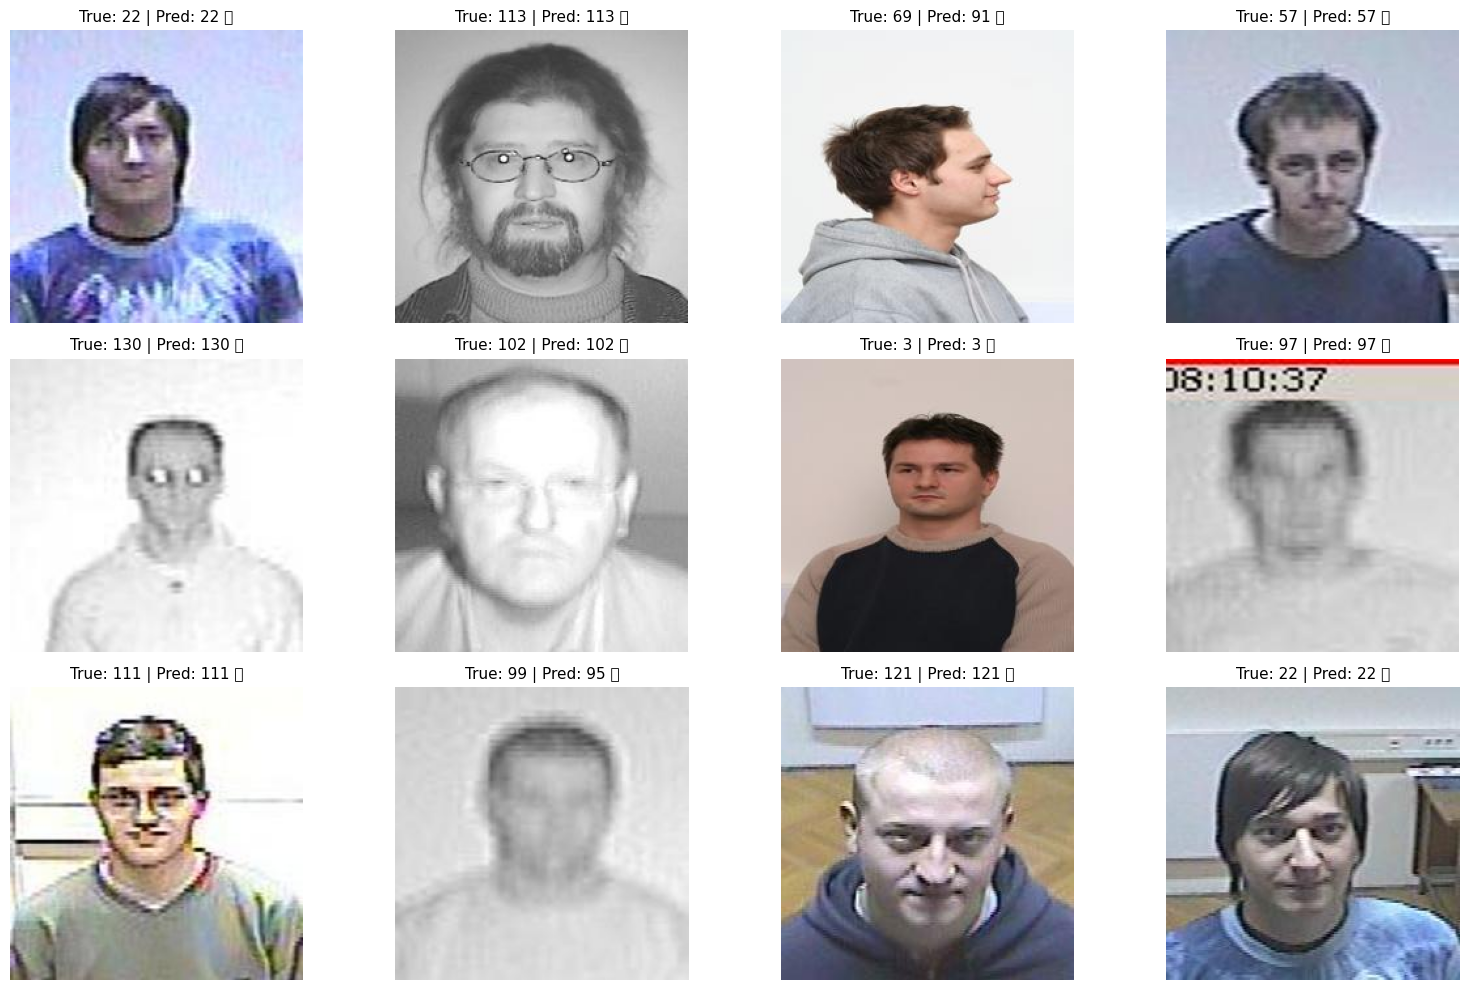

In [73]:
visual_test_predictions(
    model=model_rf,
    test_df=test_df,
    X_test=X_test,
    y_test=y_test,
    n=12,
    img_col="processed_path"
)


In [ ]:
X = np.vstack(df["embedding"].values)   
y = df["person_id"]

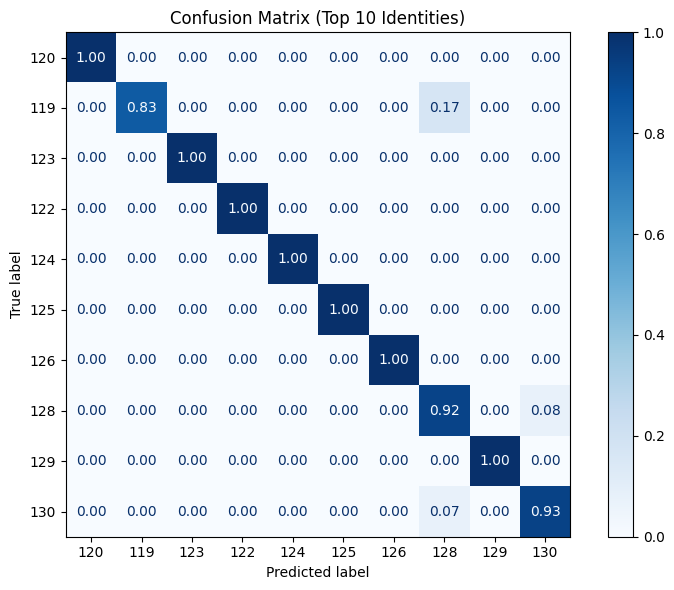

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = y_test.detach().cpu().numpy() if hasattr(y_test, "detach") else np.array(y_test)
y_pred = model_rf.predict(X_test)


unique, counts = np.unique(y_true, return_counts=True)
top10_labels = unique[np.argsort(counts)[-10:]]


mask = np.isin(y_true, top10_labels)
y_true_top = y_true[mask]
y_pred_top = y_pred[mask]


cm = confusion_matrix(y_true_top, y_pred_top, labels=top10_labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top10_labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
ax.set_title("Confusion Matrix (Top 10 Identities)")
plt.tight_layout()
plt.show()


# Test the accuracy after " Blur , Brightness , Contrast "

In [77]:
import os
from PIL import Image, ImageEnhance, ImageFilter

DEG_DIR = "./degraded_test_images"
os.makedirs(DEG_DIR, exist_ok=True)

def degrade_image(in_path, out_path, brightness=1.0, contrast=1.0, blur_radius=0.0):
    img = Image.open(in_path).convert("RGB")

    # brightness
    if brightness != 1.0:
        img = ImageEnhance.Brightness(img).enhance(brightness)

    # contrast
    if contrast != 1.0:
        img = ImageEnhance.Contrast(img).enhance(contrast)

    # blur
    if blur_radius and blur_radius > 0:
        img = img.filter(ImageFilter.GaussianBlur(radius=float(blur_radius)))

    img.save(out_path, quality=95)
    return out_path

def build_degraded_paths(test_df, setting_name, brightness=1.0, contrast=1.0, blur_radius=0.0,
                         img_col="processed_path"):
    out_paths = []
    for idx, row in test_df.reset_index(drop=True).iterrows():
        in_path = row[img_col]
        out_path = os.path.join(DEG_DIR, f"{setting_name}_{idx:06d}.jpg")
        degrade_image(in_path, out_path, brightness=brightness, contrast=contrast, blur_radius=blur_radius)
        out_paths.append(out_path)
    return out_paths


In [81]:
import pandas as pd
from sklearn.metrics import accuracy_score
import numpy as np

test_df = test_df.reset_index(drop=True)
y_test_np = np.array(y_test)

assert len(test_df) == len(y_test_np)

degradation_settings = [
    ("clean",            1.0, 1.0, 0.0),

    ("brightness_low",   0.7, 1.0, 0.0),
    ("brightness_high",  1.3, 1.0, 0.0),

    ("contrast_low",     1.0, 0.7, 0.0),
    ("contrast_high",    1.0, 1.3, 0.0),

    ("blur_1",           1.0, 1.0, 1.0),
    ("blur_2",           1.0, 1.0, 2.0),
    ("blur_3",           1.0, 1.0, 3.0),

    ("combo_medium",     0.75, 0.75, 2.0),
    ("combo_strong",     0.65, 0.65, 3.0),
]

results = []

y_pred_clean = model_rf.predict(X_test)
acc_clean = accuracy_score(y_test_np, y_pred_clean)
results.append({"setting": "clean_existing_X_test", "accuracy": acc_clean, "drop_vs_clean": 0.0})

for name, b, c, br in degradation_settings:
    if name == "clean":
        continue  

    deg_paths = build_degraded_paths(test_df, name, brightness=b, contrast=c, blur_radius=br,
                                     img_col="processed_path")

    deg_embs = embed_paths(deg_paths, model_name="Facenet")

    ok_idx = [i for i, e in enumerate(deg_embs) if e is not None]
    if len(ok_idx) == 0:
        results.append({"setting": name, "accuracy": np.nan, "drop_vs_clean": np.nan})
        continue

    X_deg = np.vstack([deg_embs[i] for i in ok_idx])
    y_deg = y_test_np[ok_idx]

    X_deg_s = scaler.transform(X_deg)

    y_pred_deg = model_rf.predict(X_deg_s)
    acc_deg = accuracy_score(y_deg, y_pred_deg)

    results.append({
        "setting": name,
        "accuracy": acc_deg,
        "drop_vs_clean": acc_clean - acc_deg,
        "kept_samples": len(ok_idx),
        "total_samples": len(test_df)
    })

res_df = pd.DataFrame(results).sort_values("drop_vs_clean", ascending=False)
res_df


Embedding degraded: 100%|██████████| 1788/1788 [06:35<00:00,  4.52it/s]


,setting,accuracy,drop_vs_clean,kept_samples,total_samples
9,combo_strong,0.013982,0.817114,1788.0,1788.0
7,blur_3,0.054810,0.776286,1788.0,1788.0
8,combo_medium,0.077181,0.753915,1788.0,1788.0
6,blur_2,0.277405,0.553691,1788.0,1788.0
1,brightness_low,0.636465,0.194631,1788.0,1788.0
3,contrast_low,0.645973,0.185123,1788.0,1788.0
2,brightness_high,0.658277,0.172819,1788.0,1788.0
5,blur_1,0.676734,0.154362,1788.0,1788.0
4,contrast_high,0.747204,0.083893,1788.0,1788.0
0,clean_existing_X_test,0.831096,0.000000,NaN,NaN


# Done